# Iris Flower Classification

## CodeAlpha Data Science Internship

This project uses machine learning to classify Iris flowers into Setosa, Versicolor, and Virginica species based on their flower measurements.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df["target"] = iris.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# Count the number of samples in each species
print("Species Distribution:")
print(pd.Series(iris.target).value_counts().sort_index())

print("\nSpecies Names:")
print(iris.target_names)

Species Distribution:
0    50
1    50
2    50
Name: count, dtype: int64

Species Names:
['setosa' 'versicolor' 'virginica']


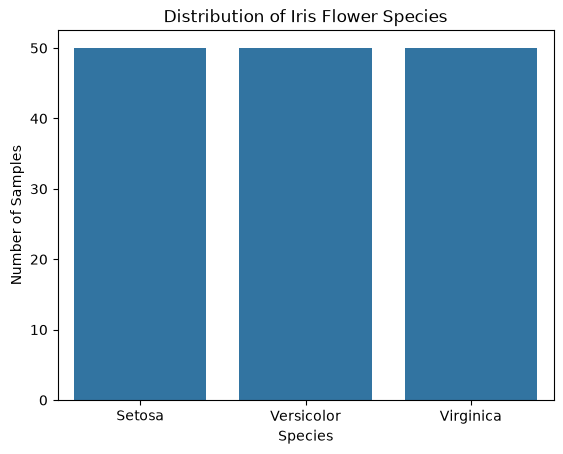

In [6]:
# Visualize the distribution of flower species
sns.countplot(x="target", data=df)

plt.title("Distribution of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

plt.show()

In [7]:
# Define features (X) and target (y)

X = df[iris.feature_names]
y = df["target"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [8]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [9]:
# Create the Machine Learning model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %


### Model Accuracy

The Decision Tree Classifier achieved an accuracy of **93.33%** on the test dataset.

In [11]:
# Generate classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



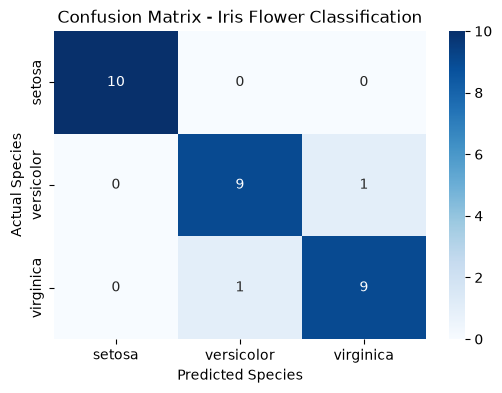

In [12]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Iris Flower Classification")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [13]:
# Get feature importance from the Decision Tree model
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
2  petal length (cm)    0.558568
3   petal width (cm)    0.406015
1   sepal width (cm)    0.029167
0  sepal length (cm)    0.006250


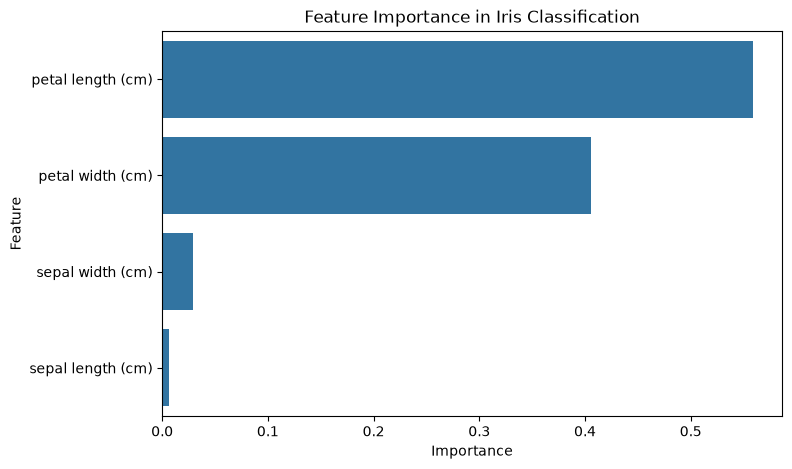

In [14]:
# Visualize feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance in Iris Classification")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [15]:
# Predict the species of a new Iris flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Species:", predicted_species)

Predicted Species: setosa


e:\Program Files\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Conclusion

The Iris flower classification model successfully classified Iris flower species using their sepal and petal measurements.

A Decision Tree Classifier was trained and evaluated using a train-test split. The model achieved an accuracy of 93.33% on the test dataset.

The project demonstrates a basic machine learning classification workflow, including data exploration, visualization, model training, prediction, and performance evaluation.